In [343]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string

from nltk import ngrams
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [344]:
#pip install openpyxl

In [345]:
speeches = pd.read_excel('1presidential_speeches_with_metadata.xlsx')

In [346]:
speeches.head()

,President,Party,from,until,Vice President,title,date,info,speech
0,Donald Trump,Republican,2017,2021,1.0,"January 8, 2020: Statement on Iran",2020-01-08 00:00:00,After the killing of General Qasem Soleimani o...,As long as I am President of the United States...
1,Donald Trump,Republican,2017,2021,1.0,"January 3, 2020: Remarks on the Killing of Qas...",2020-01-03 00:00:00,President Trump announces that the US military...,"Hello, everybody. Well, thank you very much. ..."
2,Donald Trump,Republican,2017,2021,1.0,"October 27, 2019: Statement on the the Death o...",2019-10-27 00:00:00,President Donald Trump announces the death of ...,"Last night, the United States brought the worl..."
3,Donald Trump,Republican,2017,2021,1.0,"September 25, 2019: Press Conference",2019-09-25 00:00:00,President Donald Trump holds a press conferenc...,PRESIDENT TRUMP: Thank you very much. Thank...
4,Donald Trump,Republican,2017,2021,1.0,"September 24, 2019: Remarks at the United Nati...",2019-09-24 00:00:00,President Donald Trump speaks to the 74th sess...,PRESIDENT TRUMP: Thank you very much. Mr. ...


In [347]:
#Clean data
#all_words = " ".join(speeches["speech"]).lower().split()

speeches["speech_clean"] = (
    speeches["speech"]
    .str.translate(
        str.maketrans("", "", string.punctuation)
    )
)

speeches['speech_clean'] = speeches["speech_clean"].str.lower()

#reviews["clean_review"].head()

#Counter(all_words).most_common(15)

In [348]:
stopwords = set(ENGLISH_STOP_WORDS)

speeches["speech_clean"] = speeches["speech_clean"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stopwords
    )
)

speeches["speech_clean"].head()

0    long president united states iran allowed nucl...
1    hello everybody thank good afternoon president...
2    night united states brought world’s number ter...
3    president trump thank thank thank we’ve tremen...
4    president trump thank mr president mr secretar...
Name: speech_clean, dtype: object

In [349]:
clean_words = " ".join(
    speeches["speech_clean"]
).split()

Counter(clean_words).most_common(15)

[('states', 9989),
 ('people', 9043),
 ('government', 8988),
 ('united', 8498),
 ('congress', 5486),
 ('country', 5266),
 ('world', 5233),
 ('american', 4986),
 ('time', 4896),
 ('great', 4866),
 ('new', 4863),
 ('president', 4770),
 ('war', 4428),
 ('peace', 4024),
 ('years', 3964)]

In [350]:
common_words = pd.DataFrame(
    Counter(clean_words).most_common(10),
    columns=["word","count"]
)

<Axes: title={'center': 'Most Common Words in Presidential Speeches'}, xlabel='word'>

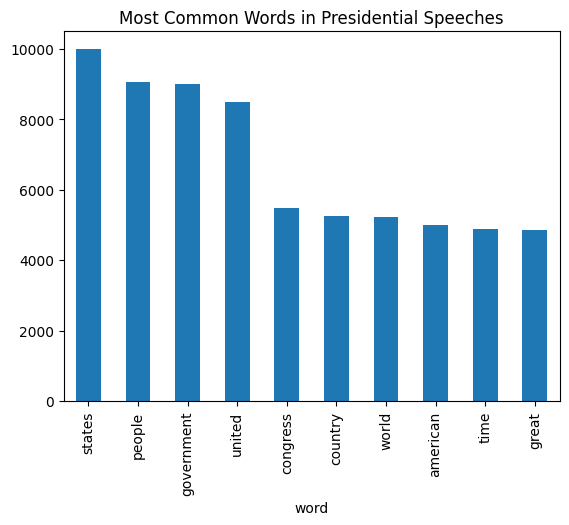

In [351]:
common_words.plot.bar(
    x="word",
    y="count",
    legend=False,
    title="Most Common Words in Presidential Speeches"
)

In [352]:
speeches.head()

,President,Party,from,until,Vice President,title,date,info,speech,speech_clean
0,Donald Trump,Republican,2017,2021,1.0,"January 8, 2020: Statement on Iran",2020-01-08 00:00:00,After the killing of General Qasem Soleimani o...,As long as I am President of the United States...,long president united states iran allowed nucl...
1,Donald Trump,Republican,2017,2021,1.0,"January 3, 2020: Remarks on the Killing of Qas...",2020-01-03 00:00:00,President Trump announces that the US military...,"Hello, everybody. Well, thank you very much. ...",hello everybody thank good afternoon president...
2,Donald Trump,Republican,2017,2021,1.0,"October 27, 2019: Statement on the the Death o...",2019-10-27 00:00:00,President Donald Trump announces the death of ...,"Last night, the United States brought the worl...",night united states brought world’s number ter...
3,Donald Trump,Republican,2017,2021,1.0,"September 25, 2019: Press Conference",2019-09-25 00:00:00,President Donald Trump holds a press conferenc...,PRESIDENT TRUMP: Thank you very much. Thank...,president trump thank thank thank we’ve tremen...
4,Donald Trump,Republican,2017,2021,1.0,"September 24, 2019: Remarks at the United Nati...",2019-09-24 00:00:00,President Donald Trump speaks to the 74th sess...,PRESIDENT TRUMP: Thank you very much. Mr. ...,president trump thank mr president mr secretar...


In [353]:
speeches['ngrams'] = speeches['speech_clean'].apply(lambda x: list(ngrams(str(x).split(), 2)))

In [354]:
bigrams_list = []

# for speech in speeches:
for ngram_list in speeches['ngrams']:
    for item in ngram_list: 
        bigrams_list.append(item)

print(bigrams_list[:100])

[('long', 'president'), ('president', 'united'), ('united', 'states'), ('states', 'iran'), ('iran', 'allowed'), ('allowed', 'nuclear'), ('nuclear', 'weapon'), ('weapon', 'good'), ('good', 'morning'), ('morning', 'i’m'), ('i’m', 'pleased'), ('pleased', 'inform'), ('inform', 'american'), ('american', 'people'), ('people', 'extremely'), ('extremely', 'grateful'), ('grateful', 'happy'), ('happy', 'americans'), ('americans', 'harmed'), ('harmed', 'night’s'), ('night’s', 'attack'), ('attack', 'iranian'), ('iranian', 'regime'), ('regime', 'suffered'), ('suffered', 'casualties'), ('casualties', 'soldiers'), ('soldiers', 'safe'), ('safe', 'minimal'), ('minimal', 'damage'), ('damage', 'sustained'), ('sustained', 'military'), ('military', 'bases'), ('bases', 'great'), ('great', 'american'), ('american', 'forces'), ('forces', 'prepared'), ('prepared', 'iran'), ('iran', 'appears'), ('appears', 'standing'), ('standing', 'good'), ('good', 'thing'), ('thing', 'parties'), ('parties', 'concerned'), ('co

In [355]:
Counter(bigrams_list).most_common(15)

[(('united', 'states'), 7453),
 (('american', 'people'), 1063),
 (('mr', 'president'), 663),
 (('years', 'ago'), 632),
 (('great', 'britain'), 589),
 (('soviet', 'union'), 537),
 (('federal', 'government'), 518),
 (('united', 'nations'), 513),
 (('men', 'women'), 498),
 (('house', 'representatives'), 427),
 (('health', 'care'), 412),
 (('president', 'united'), 376),
 (('q', 'mr'), 375),
 (('middle', 'east'), 353),
 (('states', 'america'), 340)]

In [356]:
presidents = ['George Washington',
 'John Adams',       
 'Thomas Jefferson', 
 'James Madison',    
 'James Monroe',     
 'John Quincy Adams',
 'Andrew Jackson',   
 'Martin Van Buren',
 'William Henry Harrison',
 'John Tyler',
 'James K. Polk',
 'Zachary Taylor',
 'Millard Fillmore',
 'Franklin Pierce',
 'James Buchanan',
 'Abraham Lincoln',
 'Andrew Johnson',
 'Ulysses S. Grant',
 'Rutherford B. Hayes',
 'James A. Garfield',
 'Chester A. Arthur',
 'Grover Cleveland',
 'Benjamin Harrison',
 'Grover Cleveland',
 'William McKinley',
 'Theodore Roosevelt',
 'William Howard Taft',
 'Woodrow Wilson',
 'Warren G. Harding',
 'Calvin Coolidge',
 'Herbert Hoover',
 'Franklin D. Roosevelt',
 'Harry S. Truman',
 'Dwight D. Eisenhower',
 'John F. Kennedy',
 'Lyndon B. Johnson',
 'Richard Nixon',
 'Gerald Ford',
 'Jimmy Carter',
 'Ronald Reagan',
 'George H. W. Bush',
 'Bill Clinton',
 'George W. Bush',
 'Barack Obama',
 'Donald Trump',
 'Joe Biden'
 ]

presidents_lower = []

for i in range(0, len(presidents), 1): 
    presidents_lower.append((presidents[i].split()[-1]).lower())

In [357]:
# presidents_references = []

# #this doesn't work because they refer to each other by last name 
# def find_prez(x):
#     #for bigram in list of ngrams
#     for item in x: 
#         bigram = f"{item[0]}{item[1]}"
#         if bigram in presidents: 
#             print(bigram) 
#             presidents_references.append(bigram) 
# speeches['prez_found'] = speeches['ngrams'].apply(lambda x: find_prez(x))

In [358]:
presidents_lower
presidents_lower.append('b. johnson')
presidents_lower.append('h.w. bush')
presidents_lower.append('q. adams')


In [359]:
president_map = {
    'George Washington': 'washington',
    'John Adams': 'adams',    
    'Thomas Jefferson': 'jefferson',
    'James Madison': 'madison',    
    'James Monroe': 'monroe',     
    'John Quincy Adams': 'adams',
    'Andrew Jackson': 'jackson',   
    'Martin Van Buren': 'buren',
    'William Henry Harrison': 'harrison',
    'John Tyler': 'tyler',
    'James K. Polk': 'polk',
    'Zachary Taylor': 'taylor',
    'Millard Fillmore': 'fillmore',
    'Franklin Pierce': 'pierce',
    'James Buchanan': 'buchanan',
    'Abraham Lincoln': 'lincoln',
    'Andrew Johnson': 'johnson',
    'Ulysses S. Grant': 'grant',
    'Rutherford B. Hayes': 'hayes',
    'James A. Garfield': 'garfield',
    'Chester A. Arthur': 'arthur',
    'Grover Cleveland': 'cleveland',
    'Benjamin Harrison': 'harrison',
    'William McKinley': 'mckinley',
    'Theodore Roosevelt': 'roosevelt',
    'William Howard Taft': 'taft',
    'Woodrow Wilson': 'wilson',
    'Warren G. Harding': 'harding',
    'Calvin Coolidge': 'coolidge',
    'Herbert Hoover': 'hoover',
    'Franklin D. Roosevelt': 'roosevelt',
    'Harry S. Truman': 'truman',
    'Dwight D. Eisenhower': 'eisenhower',
    'John F. Kennedy': 'kennedy',
    'Lyndon B. Johnson': 'johnson',
    'Richard Nixon': 'nixon',
    'Gerald Ford': 'ford',
    'Jimmy Carter': 'carter',
    'Ronald Reagan': 'reagan',
    'George H. W. Bush': 'bush',
    'Bill Clinton': 'clinton',
    'George W. Bush': 'bush',
    'Barack Obama': 'obama',
    'Donald Trump': 'trump',
    'Joe Biden': 'biden'
}

speeches['President'] = speeches['President'].map(president_map)

In [360]:
speeches.head()

,President,Party,from,until,Vice President,title,date,info,speech,speech_clean,ngrams
0,trump,Republican,2017,2021,1.0,"January 8, 2020: Statement on Iran",2020-01-08 00:00:00,After the killing of General Qasem Soleimani o...,As long as I am President of the United States...,long president united states iran allowed nucl...,"[(long, president), (president, united), (unit..."
1,trump,Republican,2017,2021,1.0,"January 3, 2020: Remarks on the Killing of Qas...",2020-01-03 00:00:00,President Trump announces that the US military...,"Hello, everybody. Well, thank you very much. ...",hello everybody thank good afternoon president...,"[(hello, everybody), (everybody, thank), (than..."
2,trump,Republican,2017,2021,1.0,"October 27, 2019: Statement on the the Death o...",2019-10-27 00:00:00,President Donald Trump announces the death of ...,"Last night, the United States brought the worl...",night united states brought world’s number ter...,"[(night, united), (united, states), (states, b..."
3,trump,Republican,2017,2021,1.0,"September 25, 2019: Press Conference",2019-09-25 00:00:00,President Donald Trump holds a press conferenc...,PRESIDENT TRUMP: Thank you very much. Thank...,president trump thank thank thank we’ve tremen...,"[(president, trump), (trump, thank), (thank, t..."
4,trump,Republican,2017,2021,1.0,"September 24, 2019: Remarks at the United Nati...",2019-09-24 00:00:00,President Donald Trump speaks to the 74th sess...,PRESIDENT TRUMP: Thank you very much. Mr. ...,president trump thank mr president mr secretar...,"[(president, trump), (trump, thank), (thank, m..."


In [361]:
#this doesn't work because they refer to each other by last name 
def find_prez(x):
    presidents_references = []
    #for bigram in list of ngrams
    
    for president in presidents_lower:
        #print(president)
        if (president in x['speech_clean']) and (president != x['President']):
            #print('match found')
            presidents_references.append(president) 
    return presidents_references
        

In [362]:
speeches['prez_found'] = speeches.apply(lambda x: find_prez(x), axis = 1)

In [363]:
speeches.head()

,President,Party,from,until,Vice President,title,date,info,speech,speech_clean,ngrams,prez_found
0,trump,Republican,2017,2021,1.0,"January 8, 2020: Statement on Iran",2020-01-08 00:00:00,After the killing of General Qasem Soleimani o...,As long as I am President of the United States...,long president united states iran allowed nucl...,"[(long, president), (president, united), (unit...",[]
1,trump,Republican,2017,2021,1.0,"January 3, 2020: Remarks on the Killing of Qas...",2020-01-03 00:00:00,President Trump announces that the US military...,"Hello, everybody. Well, thank you very much. ...",hello everybody thank good afternoon president...,"[(hello, everybody), (everybody, thank), (than...",[]
2,trump,Republican,2017,2021,1.0,"October 27, 2019: Statement on the the Death o...",2019-10-27 00:00:00,President Donald Trump announces the death of ...,"Last night, the United States brought the worl...",night united states brought world’s number ter...,"[(night, united), (united, states), (states, b...",[]
3,trump,Republican,2017,2021,1.0,"September 25, 2019: Press Conference",2019-09-25 00:00:00,President Donald Trump holds a press conferenc...,PRESIDENT TRUMP: Thank you very much. Thank...,president trump thank thank thank we’ve tremen...,"[(president, trump), (trump, thank), (thank, t...","[washington, johnson, johnson, obama, biden]"
4,trump,Republican,2017,2021,1.0,"September 24, 2019: Remarks at the United Nati...",2019-09-24 00:00:00,President Donald Trump speaks to the 74th sess...,PRESIDENT TRUMP: Thank you very much. Mr. ...,president trump thank mr president mr secretar...,"[(president, trump), (trump, thank), (thank, m...","[johnson, grant, johnson]"


In [364]:
president1 = []
president2 = []

def grab_prez_names(row):
    # Check if the list exists and is not empty
    if isinstance(row['prez_found'], list) and len(row['prez_found']) > 0:
        for found in row['prez_found']: 
            # Append the speaker (the president who gave the speech)
            president1.append(row['President'])
            # Append the mentioned president
            president2.append(found)

speeches.apply(lambda x: grab_prez_names(x), axis =1)

0      None
1      None
2      None
3      None
4      None
       ... 
990    None
991    None
992    None
993    None
994    None
Length: 995, dtype: object

In [367]:
presidential_references_df = pd.DataFrame(data = {'President1': president1, 'President2': president2}) 
values = presidential_references_df.value_counts()
values = pd.DataFrame(values).sort_values(['President1', 'count'], ascending = False).reset_index()

In [368]:
import networkx as nx
G = nx.from_pandas_edgelist(
    values, 
    source='President1', 
    target='President2', 
    edge_attr='count',      # Stores the count as an edge property
    create_using=nx.DiGraph()
)

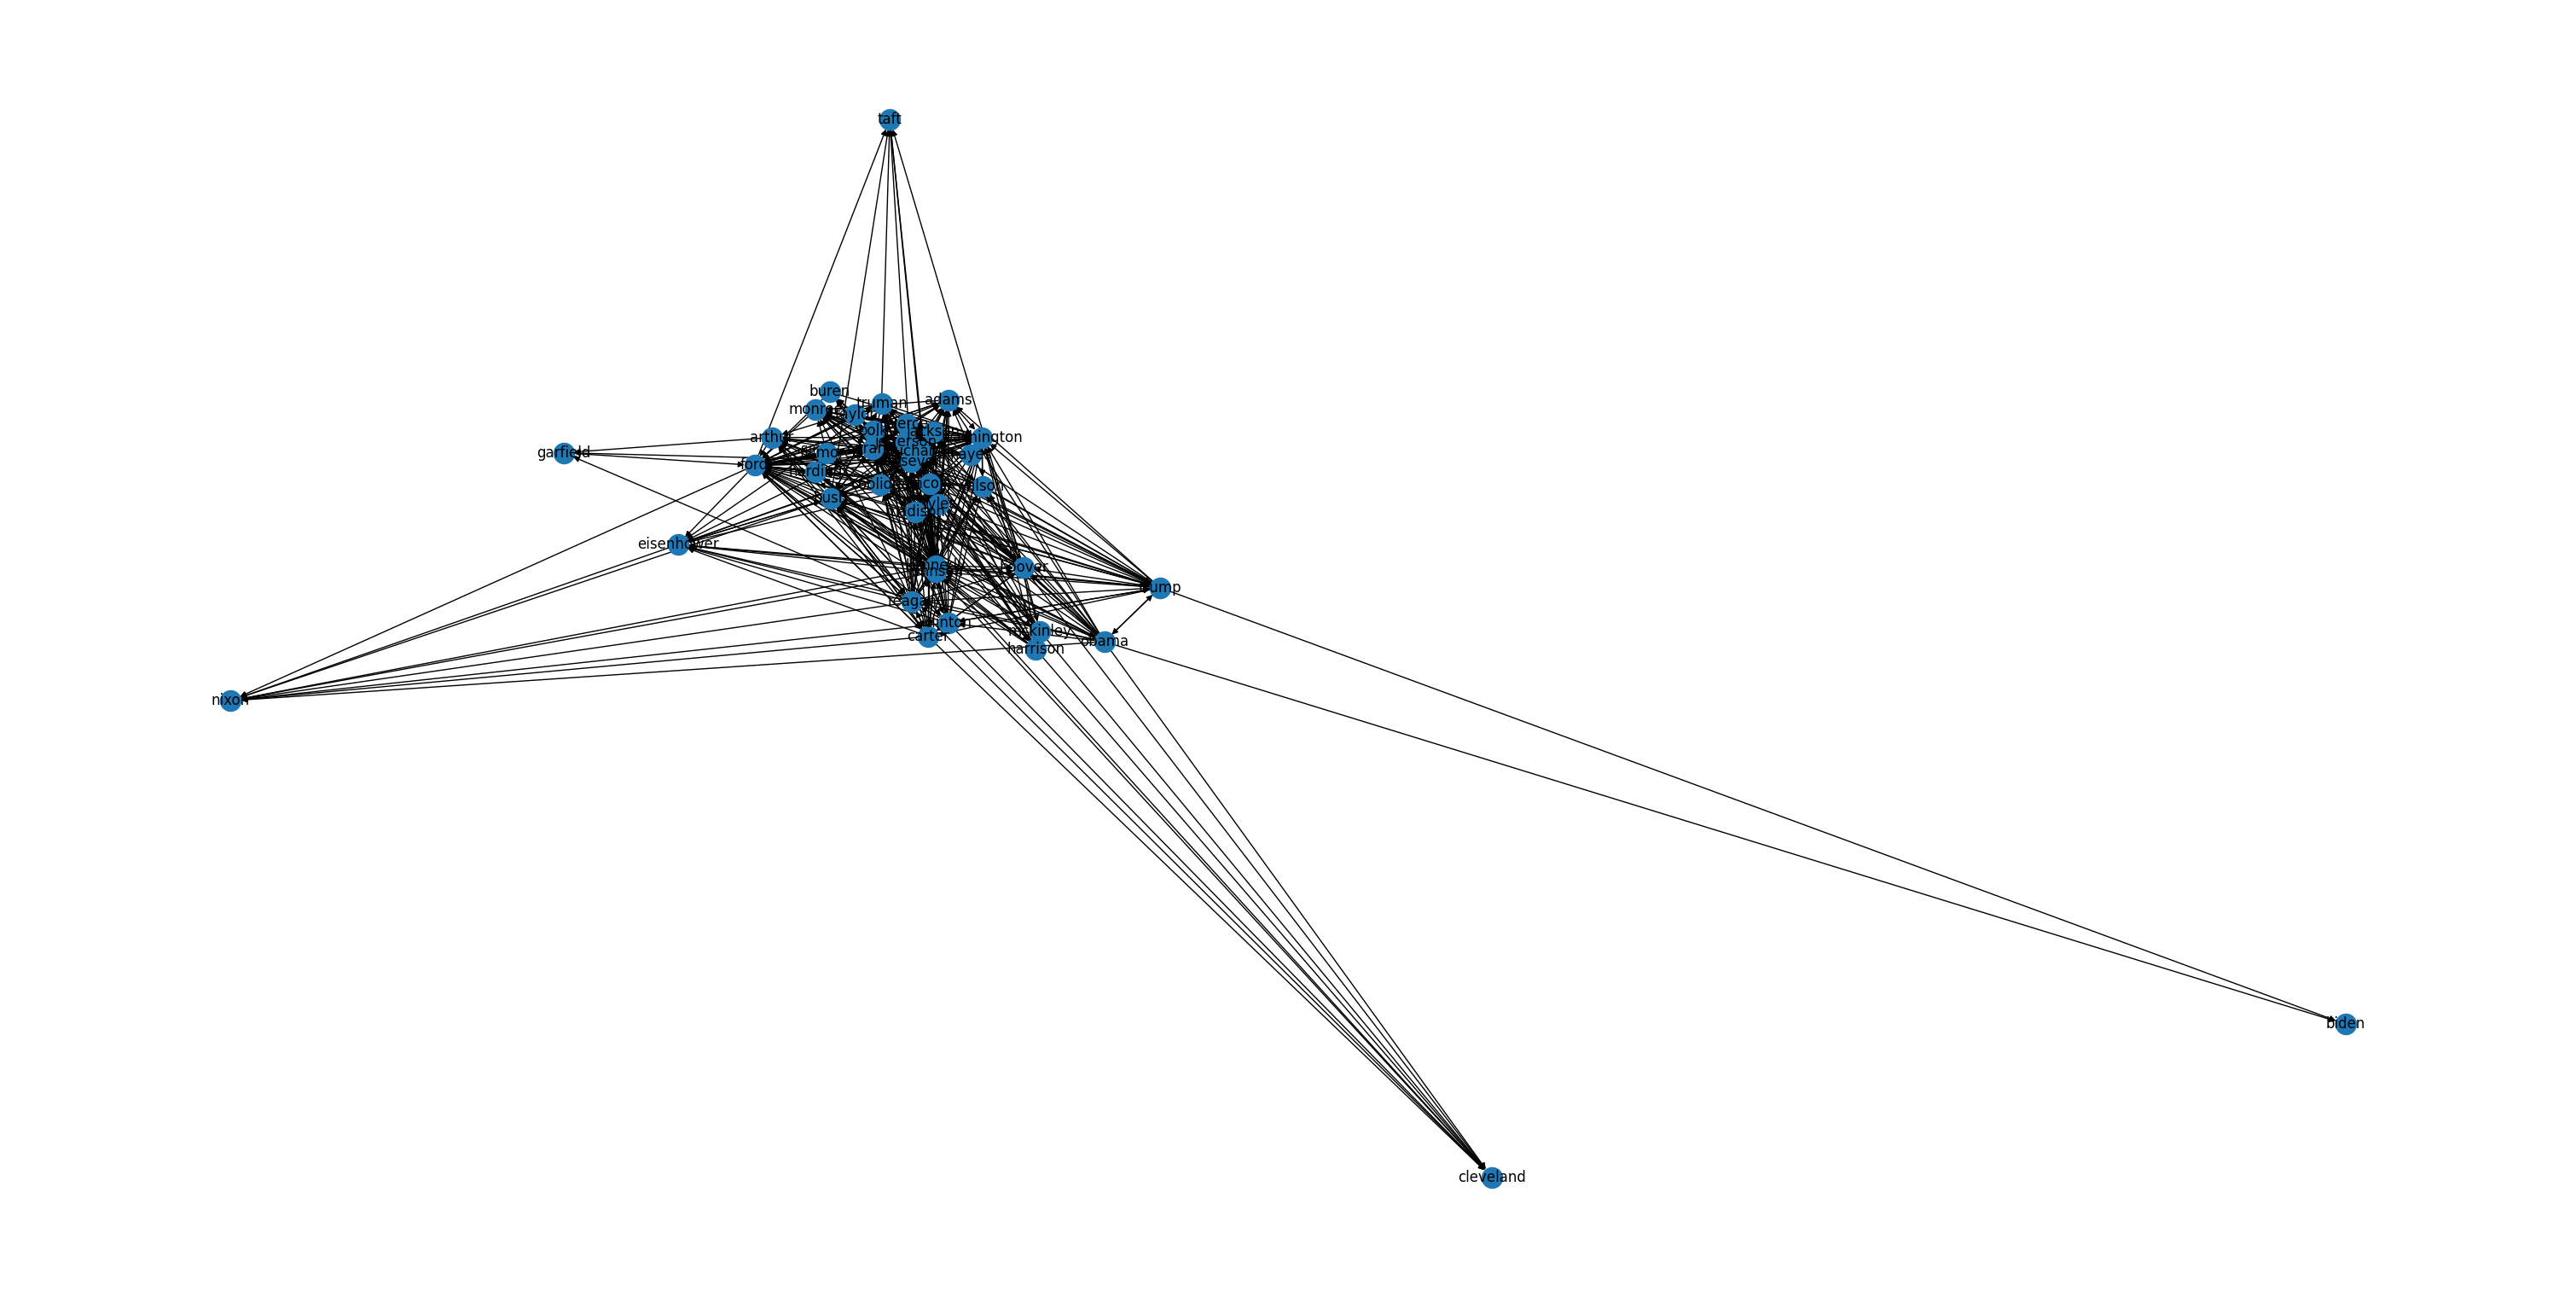

In [369]:
#make interactive (i.e. hover over one dot and can see all in degree) 
fig = plt.figure(figsize = (30, 15))
nx.draw(G, with_labels = True)

In [370]:
# in_degree_small = nx.in_degree_centrality(G)
# out_degree_small = nx.out_degree_centrality(G)

in_degree_small = G.in_degree
#print(in_degree_small)
out_degree_small = G.out_degree

In [371]:
# in_small = {key:value for (key,value) in in_degree_small.items() if value > 0.0}
# out_small = {key:value for (key,value) in out_degree_small.items() if value > 0.0}

In [372]:
# print(in_small)

In [373]:
# degrees_in = range(len(in_small))
# degrees_out= range(len(in_small))

# plt.figure(figsize=(6, 4)) 
# plt.bar(degrees_in, in_small.values(), fc = 'g', alpha = 0.5, label = 'In-Degree')
# plt.xlabel('Degree')
# plt.ylabel('Frequency')

# plt.bar(degrees_out, out_small.values(), fc = 'c', alpha = 0.5, label = 'Out-Degree')
# plt.xlabel('Degree')
# plt.ylabel('Frequency')

# plt.legend()

# plt.title('In- and Out-Degree Frequency')

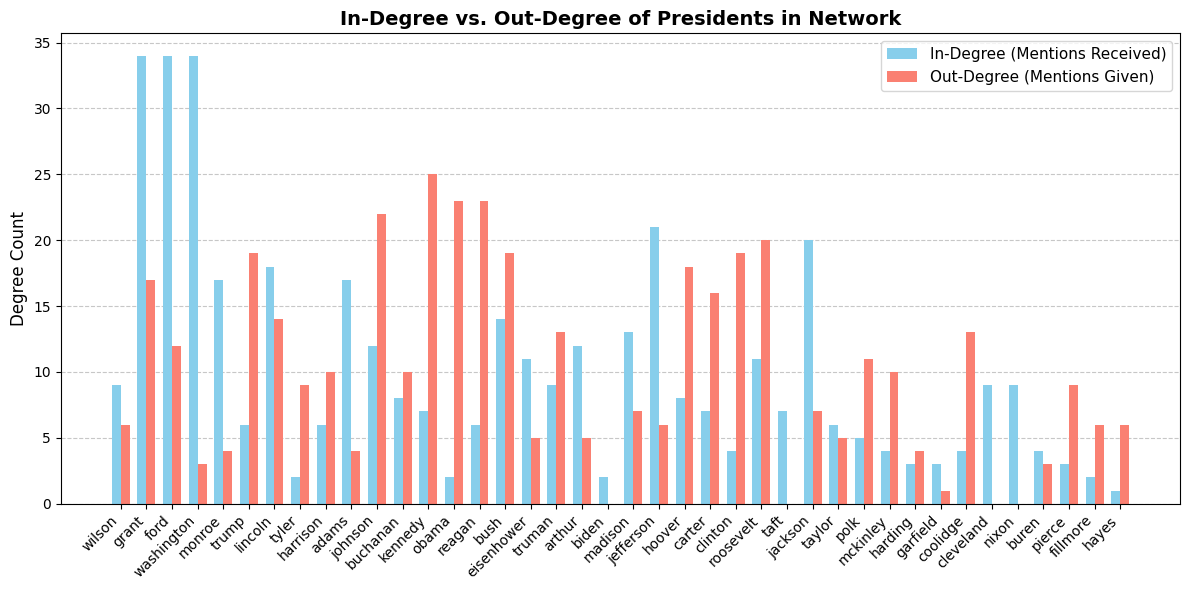

In [374]:
def plot_in_out_degrees(G):
    # 1. Extract the degrees as dictionaries
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # 2. Ensure both lists follow the exact same node order
    nodes = list(G.nodes())
    in_values = [in_degrees[node] for node in nodes]
    out_values = [out_degrees[node] for node in nodes]
    
    # 3. Set up the positions for a grouped bar chart
    x = np.arange(len(nodes))  # Label locations
    width = 0.35               # Width of each individual bar
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 4. Plot both sets of bars side-by-side
    bars_in = ax.bar(x - width/2, in_values, width, label='In-Degree (Mentions Received)', color='skyblue')
    bars_out = ax.bar(x + width/2, out_values, width, label='Out-Degree (Mentions Given)', color='salmon')
    
    # 5. Make the plot look clean and readable
    ax.set_ylabel('Degree Count', fontsize=12)
    ax.set_title('In-Degree vs. Out-Degree of Presidents in Network', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(node) for node in nodes], rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=11)
    
    # Optional: Add gridlines behind the bars for better readability
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Call the function with your graph object
plot_in_out_degrees(G)

#clearly some errors in how this is doing this because washington should NOT have any presidents that he references
#must be other fords, grants, and wilsons

#double check this because should biden have references? from obama and trump

#trump has been cited by presidents who come well before him, they probably meant trump as in triumph OR another figure 

#should check for "President Trump"

#major limitation doesn't seperate from FDR from Teddy Roosevelt, etc.  

In [381]:
values[values['President2']=='trump']

,President1,President2,count
4,wilson,trump,1
73,roosevelt,trump,1
137,obama,trump,2
198,kennedy,trump,1
343,clinton,trump,2
379,bush,trump,1


In [382]:
# TO DO : apply the pagerank() method to compute the PR values of the nodes in G
PR = nx.pagerank(G)
#PR_df = pd.DataFrame.from_dict(PR, orient = 'index', columns = ['PR'])
# PR_df = pd.from_dict(PR, orient = 'index', colums = ['President','PR'])
#PR_df.sort_values('PR').head()
# TO DO : apply the hits() method to compute the hubs and authorities values of the nodes in G

hubs, authorities = nx.hits(G)
print(hubs)
#print(authorities)

{'wilson': 0.018896623803029984, 'grant': 0.03315045948884943, 'ford': 0.028443868643467343, 'washington': 0.010084009584073865, 'monroe': 0.015718592104048308, 'trump': 0.04127287360049699, 'lincoln': 0.03014231815984838, 'tyler': 0.022889844641482363, 'harrison': 0.027727911220581953, 'adams': 0.014949325174289036, 'johnson': 0.04909070973681944, 'buchanan': 0.026578691592951488, 'kennedy': 0.04763791103679134, 'obama': 0.04855006974938001, 'reagan': 0.05109206691231824, 'bush': 0.04041210697024663, 'eisenhower': 0.015367365695269152, 'truman': 0.0347583455887196, 'arthur': 0.013332114562431004, 'biden': -0.0, 'madison': 0.02066528634464156, 'jefferson': 0.017960406675411832, 'hoover': 0.04126461386639864, 'carter': 0.03794403471301379, 'clinton': 0.044249269600192064, 'roosevelt': 0.04168821011593265, 'taft': -0.0, 'jackson': 0.02281814853162129, 'taylor': 0.01630271403536312, 'polk': 0.028410067845897127, 'mckinley': 0.024821114891196427, 'harding': 0.01510070295536932, 'garfield':

In [383]:
#PR_df.sort_values('PR', ascending = False)

In [384]:
def link_analysis_bars(result):

    fig, ax = plt.subplots(figsize=(8, 4))

   #  ax.bar(str(result.keys()), result.values(), width = 1)
   #  #ax.tick_params(axis='both', labelsize=12)
   # # ax.set_xticks(range(1,19))
   #  plt.show()

    x_labels = [str(k) for k in result.keys()]
    y_values = list(result.values())

    # Pass the separated lists into the bar chart
    ax.bar(x_labels, y_values, width = 0.6) # Shrunk width slightly so bars don't overlap
    
    # Optional: Rotate names if they crowd each other on the bottom
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout() # Ensures labels don't get cut off
    plt.show()

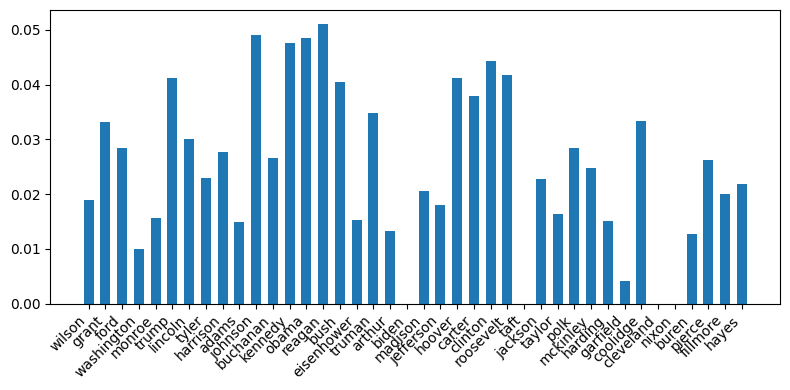

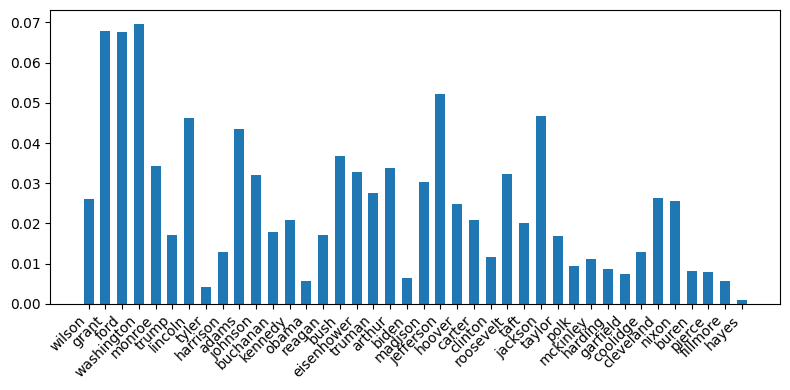

In [385]:
#link_analysis_bars(PR)
link_analysis_bars(hubs)
link_analysis_bars(authorities)

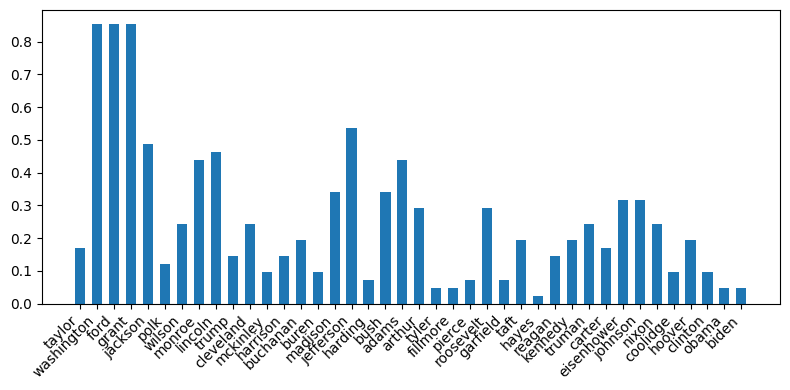

In [386]:
link_analysis_bars(in_small)


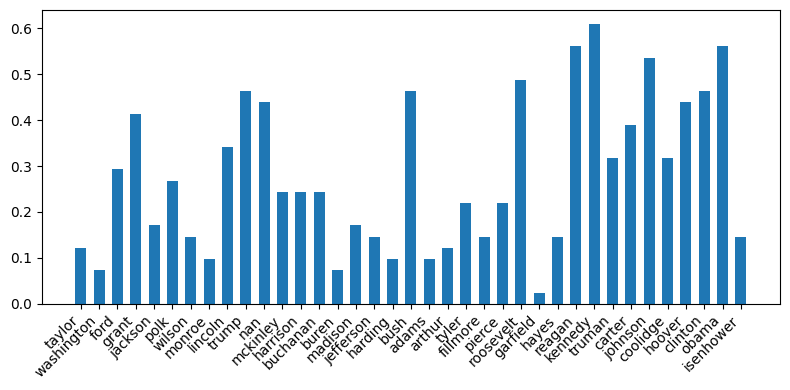

In [273]:
link_analysis_bars(out_small)